# Import Modules

In [9]:
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Data Loading and Hybrid Feature Extraction

In [19]:
# Enhanced Feature Extraction (Hybrid Set) - 63% validation accuracy, 78% training accuracy

# def extract_hybrid_features(file_path):
#     y, sr = librosa.load(file_path, duration=3, offset=0.5, res_type='soxr_hq')
    
#     # Spectral Features
#     mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
#     mfcc_scaled = np.mean(mfccs.T, axis=0)
    
#     # Tonal Features (Chroma) - Captures harmonic content
#     chroma = librosa.feature.chroma_stft(y=y, sr=sr)
#     chroma_scaled = np.mean(chroma.T, axis=0)
    
#     # Mel Spectrogram - Captures detailed frequency intensity
#     mel = librosa.feature.melspectrogram(y=y, sr=sr)
#     mel_scaled = np.mean(mel.T, axis=0)
    
#     # Prosodic Features
#     zcr = librosa.feature.zero_crossing_rate(y)
#     zcr_scaled = np.mean(zcr.T, axis=0)
    
#     rms = librosa.feature.rms(y=y)
#     rms_scaled = np.mean(rms.T, axis=0)
    
#     # Concatenate all into a single "fingerprint"
#     return np.hstack([mfcc_scaled, chroma_scaled, mel_scaled, zcr_scaled, rms_scaled])

def extract_hybrid_features(file_path, max_pad_len=128):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    
    # 1. MFCC (40)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    
    # 2. Chroma (12)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
    # 3. RMS Energy (1) - Crucial for "Volume" of emotion
    rms = librosa.feature.rms(y=y)
    
    # 4. Spectral Centroid (1) - "Brightness"
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
    # Stack them vertically to create a feature map of 54 features per time step
    combined = np.vstack([mfcc, chroma, rms, centroid]) # Shape: (54, Time)
    
    # --- PADDING / TRUNCATING ---
    # We need every file to be exactly 128 time-steps long for the LSTM
    if combined.shape[1] < max_pad_len:
        pad_width = max_pad_len - combined.shape[1]
        combined = np.pad(combined, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        combined = combined[:, :max_pad_len]
        
    return combined.T # Shape: (128, 54) -> (Time_Steps, Features)


# Full RAVDESS emotion mapping (01 to 08)
EMOTION_MAP = {'01':'neutral', '02':'calm', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

def load_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} files...")

    for file in file_list:
        emotion = EMOTION_MAP[os.path.basename(file).split('-')[2]]
        X.append(extract_hybrid_features(file))
        y.append(emotion)
            
    return np.array(X), np.array(y)


In [20]:
DATA_PATH = r"C:\Users\asus\OneDrive\Desktop\Projects\Speech_Emotion_Recognition_LSTM_RAVDESS\RAVDESS"
X_raw, y_raw = load_data(DATA_PATH)

# Scaling: We flatten to scale, then reshape back to (N, 128, 54)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.reshape(-1, X_raw.shape[-1])).reshape(X_raw.shape)

lb = LabelEncoder()
y_final = to_categorical(lb.fit_transform(y_raw))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=42)

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

Extracting hybrid features from 1440 files...
Data loaded: X_train shape (1152, 128, 54), y_train shape (1152, 8)


# Create the Hybrid BiLSTM Model

In [17]:
# Hybrid BiLSTM Model - 63% validation accuracy, 78% training accuracy

# model = Sequential([
#     # Input Layer
#     BatchNormalization(input_shape=(X.shape[1], X.shape[2])),
    
#     # Bidirectional LSTM to capture temporal context in both directions
#     Bidirectional(LSTM(256, return_sequences=True, activation='tanh')),
#     Dropout(0.3),
    
#     Bidirectional(LSTM(128, return_sequences=False, activation='tanh')),
#     Dropout(0.3),
    
#     # Dense Layers for Classification
#     Dense(128, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.4),
    
#     Dense(len(EMOTION_MAP), activation='softmax')
# ])

model = Sequential([
    # Stage 1: Convolutional layers for local spectral patterns
    Conv1D(256, 5, padding='same', activation='relu', input_shape=(128, 54)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Stage 2: Recurrent layers for temporal emotional rhythm
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(LSTM(64)),
    Dropout(0.3),

    # Stage 3: Classification head
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(8, activation='softmax')
])

# Training Configuration
opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Callbacks to maximize accuracy and prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)


In [14]:
# Train the Model
print("Starting training...")
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stop])


Starting training...
Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 358ms/step - accuracy: 0.1892 - loss: 2.6325 - val_accuracy: 0.2674 - val_loss: 1.9489 - learning_rate: 5.0000e-04
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.3082 - loss: 2.0223 - val_accuracy: 0.2222 - val_loss: 1.8599 - learning_rate: 5.0000e-04
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.3950 - loss: 1.7330 - val_accuracy: 0.3333 - val_loss: 1.7168 - learning_rate: 5.0000e-04
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 331ms/step - accuracy: 0.4661 - loss: 1.5300 - val_accuracy: 0.4410 - val_loss: 1.5735 - learning_rate: 5.0000e-04
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.5078 - loss: 1.3746 - val_accuracy: 0.4236 - val_loss: 1.4690 - learning_rate: 5.0000e-04
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 245ms/step - accuracy: 0.5720 - loss: 1.2363 - val_accuracy: 0.5556 - val_loss: 1.2901 - learning_rate: 5.0000e-04
Epoch 7/200
36/36 ━━━━━━━━━━━━━

In [15]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

print(f"Best Train Accuracy: {max(history.history['accuracy']) * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7778 - loss: 0.8229
Test Accuracy: 77.78%
Test Loss: 0.8229
Best Train Accuracy: 99.83%


# Plot the Results

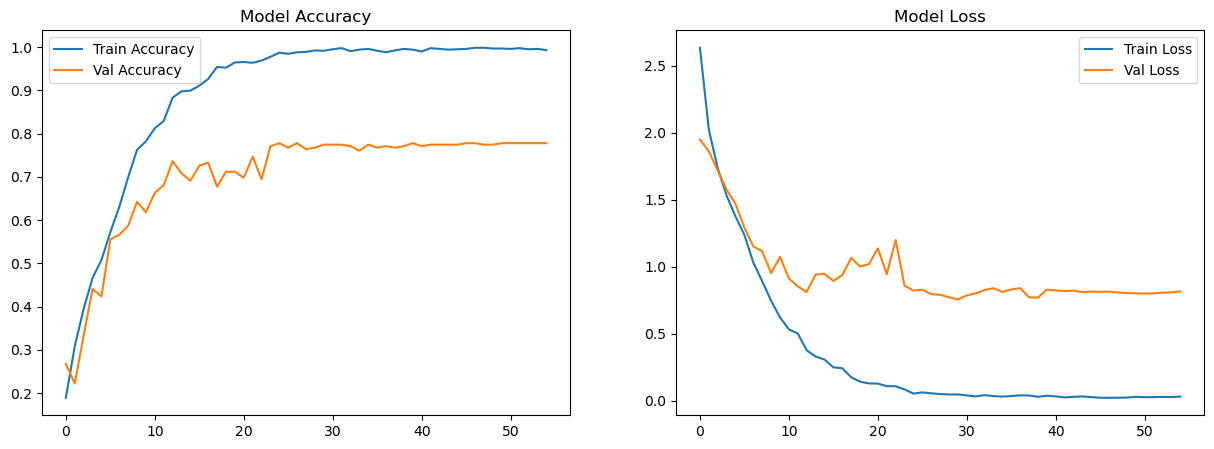

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


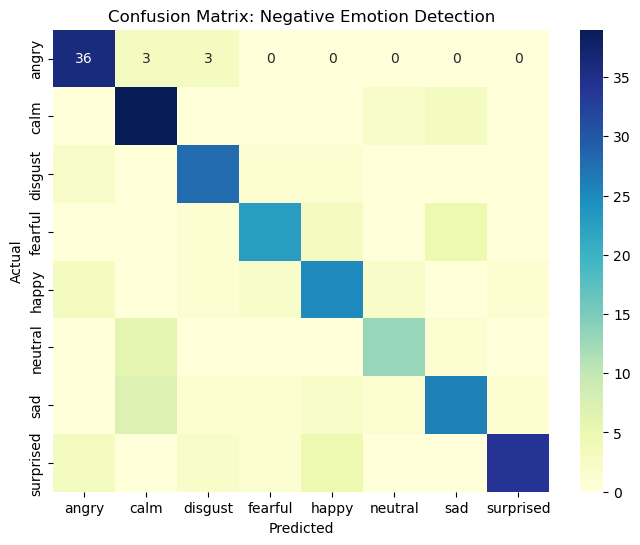


Classification Report:

              precision    recall  f1-score   support

       angry       0.82      0.86      0.84        42
        calm       0.71      0.89      0.79        44
     disgust       0.78      0.88      0.82        32
     fearful       0.82      0.72      0.77        32
       happy       0.69      0.74      0.71        34
     neutral       0.72      0.65      0.68        20
         sad       0.74      0.67      0.70        39
   surprised       0.94      0.76      0.84        45

    accuracy                           0.78       288
   macro avg       0.78      0.77      0.77       288
weighted avg       0.79      0.78      0.78       288



In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='YlGnBu')
plt.title('Confusion Matrix: Negative Emotion Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))
